<a href="https://colab.research.google.com/github/joelhrtl/DataAnalysis/blob/main/MockExam_HURTADO_LEON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MOCK EXAM - BlaBla Car - Joel Hurtado León - 20250310


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Importing & Cleaning Data

In [ ]:
# upload excel file
from google.colab import files
uploaded = files.upload()

Saving BlaBla-Car_Data.xlsx to BlaBla-Car_Data.xlsx


In [ ]:
# read excel
df = pd.read_excel('BlaBla-Car_Data.xlsx')
df

,driver_id,offer_id,departure,arrival,trip_distance,offer_date,departure_date,price,nb_offers,photo,...,mean_price_depd,sd_price_depd,seats_in_car,seat_sold,Driver_first_name,Satisfaction_Livel,nb_evaluation,driver_age,driver_gender,Premium_Club
0,123956,427719,Lyon,Paris,425.0,5-Jan-14,1/12/2014 17:30,28,526.0,0,...,29.071247,2.567809,4,0,Francois,Excellent,0,25,0,0
1,81617,280534,Lyon,Paris,429.0,2-Jan-14,1/6/2014 14:40,30,526.0,0,...,28.862133,3.189145,0,0,Corinne,Good,24,31,1,0
2,198167,657605,Lyon,Paris,429.0,2-Jan-14,1/6/2014 15:10,31,526.0,1,...,28.862133,3.189145,0,0,Laura,Excellent,1,31,1,1
3,282817,946022,Lyon,Paris,429.0,2-Jan-14,1/6/2014 15:30,25,526.0,1,...,28.862133,3.189145,3,3,Philippe,VeryGood,3,31,0,1
4,29640,94886,Lyon,Paris,435.0,5-Jan-14,1/19/2014 9:00,25,526.0,1,...,29.364803,2.784098,7,4,Antoine,VeryGood,10,26,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97620,315770,1055947,Lyon,Paris,506.0,5-Mar-14,3/14/2014 14:30,28,834.0,1,...,29.938263,3.651275,0,0,Solange,Good,2,49,1,0
97621,324044,1089104,Lyon,Paris,506.0,13-Mar-14,3/16/2014 17:45,31,834.0,0,...,29.509066,2.409041,3,0,Sylvain,Excellent,15,44,0,1
97622,175981,583045,Lyon,Paris,514.0,13-Mar-14,5/4/2014 10:05,37,834.0,1,...,30.291666,1.710135,4,2,Jerome,Good,5,44,0,0
97623,123163,423113,Lyon,Paris,528.0,13-Mar-14,4/13/2014 16:00,28,834.0,0,...,29.428572,3.178965,2,0,Franck,VeryGood,16,27,0,0


In [ ]:
 # Python code to display a summary of the basic information about the Data Frame and its data
df.shape


(97625, 32)

In [ ]:
df.info()
"numerical values by mean; categorical by mode"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97625 entries, 0 to 97624
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   driver_id           97625 non-null  int64  
 1   offer_id            97625 non-null  int64  
 2   departure           97625 non-null  object 
 3   arrival             97625 non-null  object 
 4   trip_distance       97601 non-null  float64
 5   offer_date          97625 non-null  object 
 6   departure_date      97625 non-null  object 
 7   price               97625 non-null  int64  
 8   nb_offers           97603 non-null  float64
 9   photo               97625 non-null  int64  
 10  driver_status       97625 non-null  object 
 11  music               97625 non-null  int64  
 12  talk                97625 non-null  int64  
 13  pet                 97625 non-null  int64  
 14  smoking             97625 non-null  int64  
 15  manual_reservation  97625 non-null  int64  
 16  roun

'numerical values by mean; categorical by mode'

In [ ]:
df.describe()

,driver_id,offer_id,trip_distance,price,nb_offers,photo,music,talk,pet,smoking,...,max_price_depd,min_price_depd,mean_price_depd,sd_price_depd,seats_in_car,seat_sold,nb_evaluation,driver_age,driver_gender,Premium_Club
count,97625.000000,9.762500e+04,97601.000000,97625.000000,97603.000000,97625.000000,97625.000000,97625.0,97625.000000,97625.000000,...,97625.000000,97625.000000,97625.000000,97613.000000,97625.000000,97625.000000,97625.000000,97625.000000,97625.000000,97625.000000
mean,183112.611268,6.122613e+05,467.667012,29.136020,767.564409,0.419001,0.571790,1.0,0.085163,0.058284,...,46.891431,17.492353,29.680794,3.299338,2.300026,1.159980,12.207877,34.633147,0.249209,0.249209
std,104032.508106,3.460801e+05,26.852776,3.538796,51.932390,0.493398,0.494822,0.0,0.279125,0.234281,...,18.193730,4.897133,0.679380,0.967332,1.833990,1.539941,22.740628,11.692740,0.432557,0.432557
min,10.000000,2.000000e+01,312.000000,1.000000,526.000000,0.000000,0.000000,1.0,0.000000,0.000000,...,23.000000,-1.000000,21.666666,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000
25%,91727.000000,3.207850e+05,462.000000,28.000000,761.000000,0.000000,0.000000,1.0,0.000000,0.000000,...,40.000000,15.000000,29.267822,2.752414,0.000000,0.000000,0.000000,26.000000,0.000000,0.000000
50%,187454.000000,6.151750e+05,462.000000,30.000000,785.000000,0.000000,1.000000,1.0,0.000000,0.000000,...,42.000000,20.000000,29.720201,3.079294,3.000000,0.000000,4.000000,31.000000,0.000000,0.000000
75%,277383.000000,9.169910e+05,469.000000,30.000000,798.000000,1.000000,1.000000,1.0,0.000000,0.000000,...,46.000000,20.000000,30.103077,3.506759,4.000000,2.000000,13.000000,42.000000,0.000000,0.000000
max,354871.000000,1.192932e+06,1700.000000,251.000000,834.000000,1.000000,1.000000,1.0,1.000000,1.000000,...,251.000000,38.000000,38.000000,9.647118,18.000000,15.000000,357.000000,85.000000,1.000000,1.000000


In [ ]:
# Decide to drop.na if missing value is less than 5% --> df = df.dropna()
# If missing value is more than 50% --> drop the column(s)
# If in between --> fillna (mean or mode)

In [ ]:
# List of missing values by columns
df.isna().sum()

,0
driver_id,0
offer_id,0
departure,0
arrival,0
trip_distance,24
offer_date,0
departure_date,0
price,0
nb_offers,22
photo,0


In [ ]:
# clean data by dropping nan
df = df.dropna()

In [ ]:
# Recheck missing values: I dropped them because they don't represent more than 5% of the data
df.isna().sum()

,0
driver_id,0
offer_id,0
departure,0
arrival,0
trip_distance,0
offer_date,0
departure_date,0
price,0
nb_offers,0
photo,0


Data Manipulation

In [ ]:
# Find the maximum trip distance driver name
max_dis_driver = df[df["trip_distance"] == df["trip_distance"].max()][["Driver_first_name", "trip_distance"]]
max_dis_driver

,Driver_first_name,trip_distance
94822,Claude,1700.0


In [ ]:
# Print the Minimum of " page_view “ & “ nb_offers" by ‘driver_status’ (5 points)
Min_pg_offer = df.groupby("driver_status")[["page_view", "nb_offers"]].min().reset_index()
Min_pg_offer

,driver_status,page_view,nb_offers
0,S1,0,526.0
1,S2,0,526.0
2,S3,0,526.0
3,S4,0,526.0
4,S5,0,526.0


In [ ]:
#Using the loop(for ... in ... ) to select and print by ‘‘driver_status’’, the Driver_name with the max “"detour_time"
print(f"{'driver_status':<15} | {'Driver_first_name':<20} | {'detour_time':<12}")

for status in df['driver_status'].unique():
    df_status = df[df['driver_status'] == status]

    row = df_status.loc[df_status['detour_time'].idxmax()]

    print(f"{status:<15} | {row['Driver_first_name']:<20} | {row['detour_time']:<12}")

driver_status   | Driver_first_name    | detour_time 
S2              | Julien               | 30          
S5              | Jean-Baptiste        | 30          
S3              | Armand               | 30          
S4              | Mustapha             | 30          
S1              | Marcel               | 30          


In [ ]:
# Defining Your Own Python Function with :
# - Argument = driver_id
# - Return = ( Driver_first_name, Driver_Age, Average trip_distance, Average Price )
# Using your function, print the return if the “driver_id” = ( 201315 )
def get_driver_info(driver_id):
    df_driver = df[df['driver_id'] == driver_id]

    first_name = df_driver['Driver_first_name'].iloc[0]
    age = int(df_driver['driver_age'].iloc[0])
    avg_distance = float(df_driver['trip_distance'].mean())
    avg_price = float(df_driver['price'].mean())

    return first_name, age, avg_distance, avg_price

result = get_driver_info(201315)
print("Driver_first_name:", result[0])
print("Driver_Age:", result[1])
print("Average_trip_distance:", result[2])
print("Average_Price:", result[3])

Driver_first_name: Laurent
Driver_Age: 47
Average_trip_distance: 534.6
Average_Price: 32.0


Data Visualization

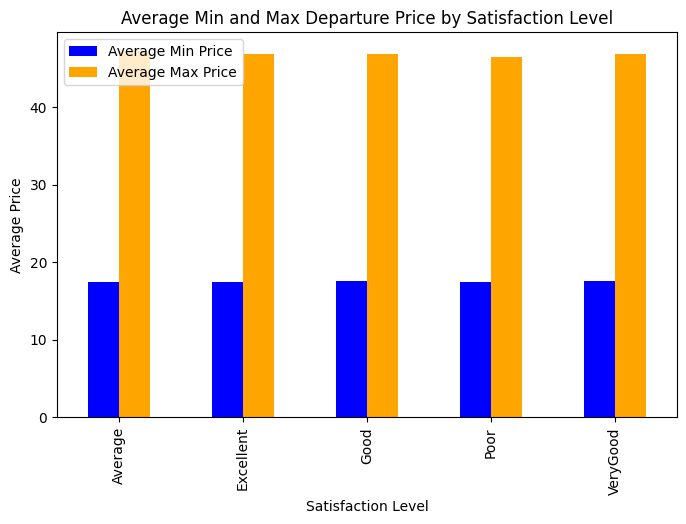

In [ ]:
# Draw the graphs with (“Title”, “Label-Name”, “Legend”, “Color”, .... Etc....)
# The Bar chart of the average of ( min_price_depd & max_price_depd ) by ‘Satisfaction_Livel’ (5 points)
avg_prices = df.groupby('Satisfaction_Livel')[['min_price_depd', 'max_price_depd']].mean()
avg_prices.plot(
    kind='bar',
    color=['blue', 'orange'],
    figsize=(8, 5)
)

plt.title("Average Min and Max Departure Price by Satisfaction Level")
plt.xlabel("Satisfaction Level")
plt.ylabel("Average Price")
plt.legend(["Average Min Price", "Average Max Price"])

plt.show()

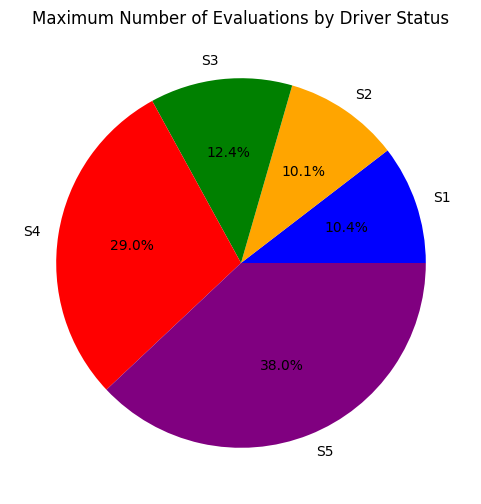

In [ ]:
# Read the maximum of ' nb_evaluation' by ‘ driver_status ‘ and show it using a Pie chart (5 points)
max_evaluation = df.groupby('driver_status')['nb_evaluation'].max()

plt.figure(figsize=(6, 6))
plt.pie(
    max_evaluation,
    labels=max_evaluation.index,
    autopct='%1.1f%%',
    colors=['blue', 'orange', 'green', 'red', 'purple']
)

plt.title("Maximum Number of Evaluations by Driver Status")
plt.show()

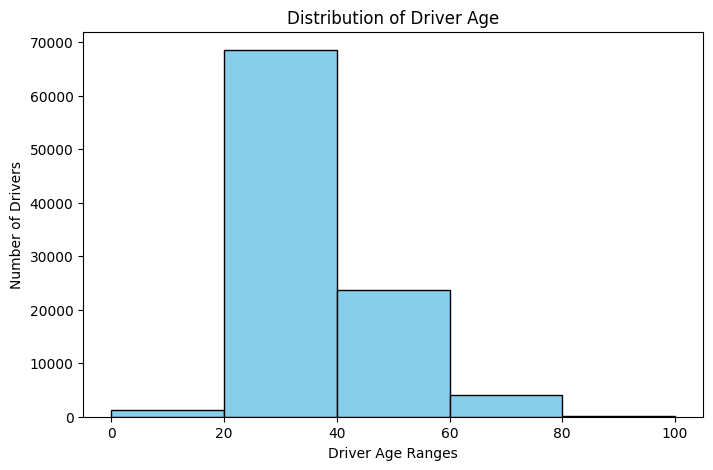

In [ ]:
# Read the “driver_age ” of each driver and show it using the histogram to see five ‘driver-age ranges
# (0-20, 21-40, 41-60, 61-80, 81-100 ) (7 points)
# Define the age ranges (bins)
bins = [0, 20, 40, 60, 80, 100]

plt.figure(figsize=(8, 5))

plt.hist(
    df['driver_age'],
    bins=bins,
    color='skyblue',
    edgecolor='black'
)

plt.title("Distribution of Driver Age")
plt.xlabel("Driver Age Ranges")
plt.ylabel("Number of Drivers")

plt.xticks(bins)

plt.show()

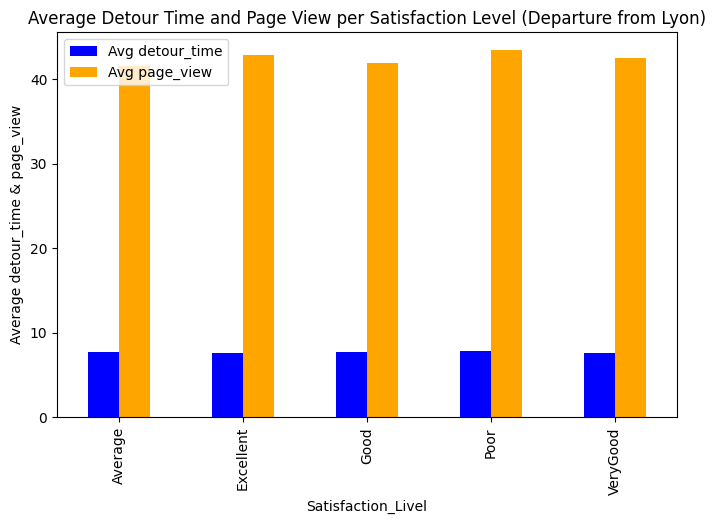

In [ ]:
#Select the liste of the “departure” from Lyon and plot the graph of the average of
#'detour_time ‘, & ' page_view ‘per “Satisfaction_Livel’’. ( X label name =
#Satisfaction_Livel’’, Y label name = detour_time ‘, & ' page_view ‘) (8 points)

df_lyon = df[df['departure'] == 'Lyon']
avg_values = df_lyon.groupby('Satisfaction_Livel')[['detour_time', 'page_view']].mean()

avg_values.plot(
    kind='bar',
    color=['blue', 'orange'],
    figsize=(8, 5)
)

plt.title("Average Detour Time and Page View per Satisfaction Level (Departure from Lyon)")
plt.xlabel("Satisfaction_Livel")
plt.ylabel("Average detour_time & page_view")
plt.legend(["Avg detour_time", "Avg page_view"])

plt.show()

Data Analysis

In [ ]:
# The Top 10 Max Business Index driver
business_df = df.groupby('driver_id').agg({
    'trip_distance': 'sum',
    'price': 'mean',
    'Driver_first_name': 'first'
})

business_df['Business_Index'] = (
    business_df['trip_distance'] *
    business_df['price']
)

top10_business = business_df.sort_values(
    by='Business_Index',
    ascending=False
).head(10)

print(top10_business[['Driver_first_name', 'trip_distance', 'price', 'Business_Index']].round(2))

          Driver_first_name  trip_distance  price  Business_Index
driver_id                                                        
305080              Samidil        48510.0  24.52      1189650.00
284076               Pierre        33989.0  30.22      1027223.11
191564                Karim        32071.0  30.28       971091.01
308156               Saphir        32340.0  29.69       960036.00
253409              Mohamed        37987.0  25.19       956910.62
349812                Yazid        30471.0  29.92       911821.59
155716                 Isma        33722.0  26.52       894325.92
293799                 Remy        27651.0  29.95       828074.68
188225               Julien        30541.0  26.91       821830.55
137549               Gilles        26333.0  29.00       763657.00


In [ ]:
# The Top 10 Max Confort_Index driver
# Step 1 — Compute Confort_Index per row
df.loc[:, 'Confort_Index'] = (
    df['car_rating'] +
    df['detour_time'] +
    df['music'] -
    df['smoking']
)

confort_df = df.groupby('driver_id').agg({
    'Driver_first_name': 'first',
    'Confort_Index': 'sum'
})

top10_confort = confort_df.sort_values(
    by='Confort_Index',
    ascending=False
).head(10)

print(top10_confort)

          Driver_first_name  Confort_Index
driver_id                                 
137549               Gilles           1007
113011               Fabien            673
282325             Philippe            562
155716                 Isma            543
87314                 David            522
111921             Ezzedine            513
240988               Matteo            452
309584            Sebastien            447
68588                 Chris            431
254129             Mohammed            420


BlaBlaCar Premium Club Prediction

In [ ]:
# Target variable
y = df['Premium_Club']
# Relevant predictors
X = df[
    [
        'trip_distance',
        'price',
        'nb_offers',
        'page_view',
        'detour_time',
        'car_rating',
        'seat_sold',
        'nb_evaluation',
        'driver_age'
    ]
]
# Handle categorical variables
df_encoded = pd.get_dummies(
    df[
        [
            'driver_gender',
            'driver_status',
            'Satisfaction_Livel'
        ]
    ],
    drop_first=True
)

X = pd.concat([X, df_encoded], axis=1)

In [ ]:
# Train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

# Predicted probabilities
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Adjusted threshold
y_pred = (y_prob >= 0.45).astype(int)

In [65]:
# Evaluate Performance
print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Insights
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTOP FEATURES DRIVING PREMIUM CLUB SUBSCRIPTION:")
print(importances)

Accuracy:
0.5190898375442013

Confusion Matrix:
[[6709 7962]
 [1422 3420]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.46      0.59     14671
           1       0.30      0.71      0.42      4842

    accuracy                           0.52     19513
   macro avg       0.56      0.58      0.51     19513
weighted avg       0.69      0.52      0.55     19513


TOP FEATURES DRIVING PREMIUM CLUB SUBSCRIPTION:
driver_gender                   0.316120
trip_distance                   0.176895
nb_offers                       0.105477
page_view                       0.076030
driver_age                      0.068680
nb_evaluation                   0.065462
price                           0.054245
seat_sold                       0.033584
car_rating                      0.029407
detour_time                     0.014388
Satisfaction_Livel_Poor         0.009039
Satisfaction_Livel_VeryGood     0.008470
Satisfaction_Livel_Excellent    0

The model shows that Premium subscription is mainly influenced by user behavior and platform engagement. Variables such as trip_distance, nb_offers, page_view, and price indicate that highly active users are more likely to subscribe. Demographic factors such as driver_gender and driver_age also contribute to prediction, suggesting differences in subscription patterns across user groups.
